# Fragment Coelution Scoring

This notebook illustrates how Osprey uses **fragment co-elution** to distinguish true
peptide peaks from interference peaks that happen to contain a CWT-detected peak
but whose fragments do not truly co-elute.

## The core idea

In DIA data, a precursor's fragment ions all come from the same peptide, so they must
**co-elute perfectly**: fragment XICs within the peak should be highly correlated with
each other.  An interference peak may pass CWT peak detection and score well spectrally (a foreign
peptide happens to have strong signal at this RT), but the individual fragment ions will
**not** track each other — they belong to different peptides with different elution
profiles.

## Features computed

| Feature | Description |
|---------|-------------|
| `fragment_coelution_sum` | Sum of all pairwise Pearson correlations between fragment XICs **within peak boundaries** |
| `fragment_coelution_min` | Minimum pairwise correlation (worst pair) |
| `n_coeluting_fragments` | Number of fragments with positive mean pairwise correlation |
| `fragment_corr_0..5` | Per-fragment average correlation with all other fragments (top 6 by library intensity) |
| `elution_weighted_cosine` | Score²-weighted average cosine similarity across every scan in the peak |

All correlations/cosines are bounded to the **peak integration window** detected by CWT
consensus — a deliberate departure from computing over the full XIC, which would dilute
interference signals.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import combinations

rng = np.random.default_rng(0)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})


def gaussian_peak(rt, apex, height, sigma):
    return height * np.exp(-0.5 * ((rt - apex) / sigma) ** 2)


def pearson(a, b):
    """Pearson correlation; returns 0 if std of either is zero."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    if a.std() < 1e-10 or b.std() < 1e-10:
        return 0.0
    return float(np.corrcoef(a, b)[0, 1])

## 1. Simulate Two Scenarios

**Scenario A — True peptide peak (RT ≈ 12 min)**  
All 6 fragments elute together. The peak has a high coelution sum.

**Scenario B — Interference peak (RT ≈ 9.5 min)**  
A CWT peak is detected with a high spectral score (a foreign peptide has strong signal at this RT),
but only 1–2 fragment ions accidentally have signal there; the rest do not.
Coelution sum is low or negative.

In [2]:
rt_full = np.linspace(8, 16, 160)  # full XIC axis

# Library fragment relative intensities (most abundant first)
lib_ints = np.array([100, 75, 60, 45, 30, 20], dtype=float)
frag_labels = ['b3²⁺', 'b4²⁺', 'y5⁺', 'y6⁺', 'y7⁺', 'b5²⁺']
frag_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ── Scenario A: true peptide peak ─────────────────────────────────────────
true_apex_rt = 12.0
peak_sigma   = 0.25

xics_A = []
for li in lib_ints:
    sig = gaussian_peak(rt_full, true_apex_rt, li, peak_sigma)
    sig += rng.normal(0, 1.5, len(rt_full))   # noise
    xics_A.append(np.clip(sig, 0, None))

# Peak boundary for Scenario A (±2σ around apex)
boundary_A = (true_apex_rt - 2 * peak_sigma, true_apex_rt + 2 * peak_sigma)

# ── Scenario B: interference peak ────────────────────────────────────────
inter_apex_rt = 9.5
inter_sigma   = 0.30

# Only 2 fragments happen to have any signal at the interference RT
interference_ints = np.array([90, 0, 80, 0, 0, 0], dtype=float)
# Each fragment has its own noise + individual small random peaks
xics_B = []
for i, li in enumerate(lib_ints):
    # The interfering peptide's fragment ions are NOT correlated across our 6 fragments
    sig = (gaussian_peak(rt_full, inter_apex_rt, interference_ints[i], inter_sigma)
           + rng.normal(0, 2.0, len(rt_full)))
    xics_B.append(np.clip(sig, 0, None))

boundary_B = (inter_apex_rt - 2 * inter_sigma, inter_apex_rt + 2 * inter_sigma)

# ── Also simulate a spectral score series (dot product at apex) ─────────────────
coef_A = gaussian_peak(rt_full, true_apex_rt,  1.0, peak_sigma )  + rng.normal(0, 0.02, len(rt_full))
coef_B = gaussian_peak(rt_full, inter_apex_rt, 0.9, inter_sigma)  + rng.normal(0, 0.02, len(rt_full))
print('Spectral score at Scenario A apex: {:.3f}'.format(
    coef_A[np.argmin(np.abs(rt_full - true_apex_rt))]))
print('Spectral score at Scenario B apex: {:.3f}'.format(
    coef_B[np.argmin(np.abs(rt_full - inter_apex_rt))]))
print('\nSpectral scores are similar — you cannot tell from the score alone which is real!')

Spectral score at Scenario A apex: 1.002
Spectral score at Scenario B apex: 0.889

Spectral scores are similar — you cannot tell from the score alone which is real!


## 2. Visualise the Fragment XICs for Both Scenarios

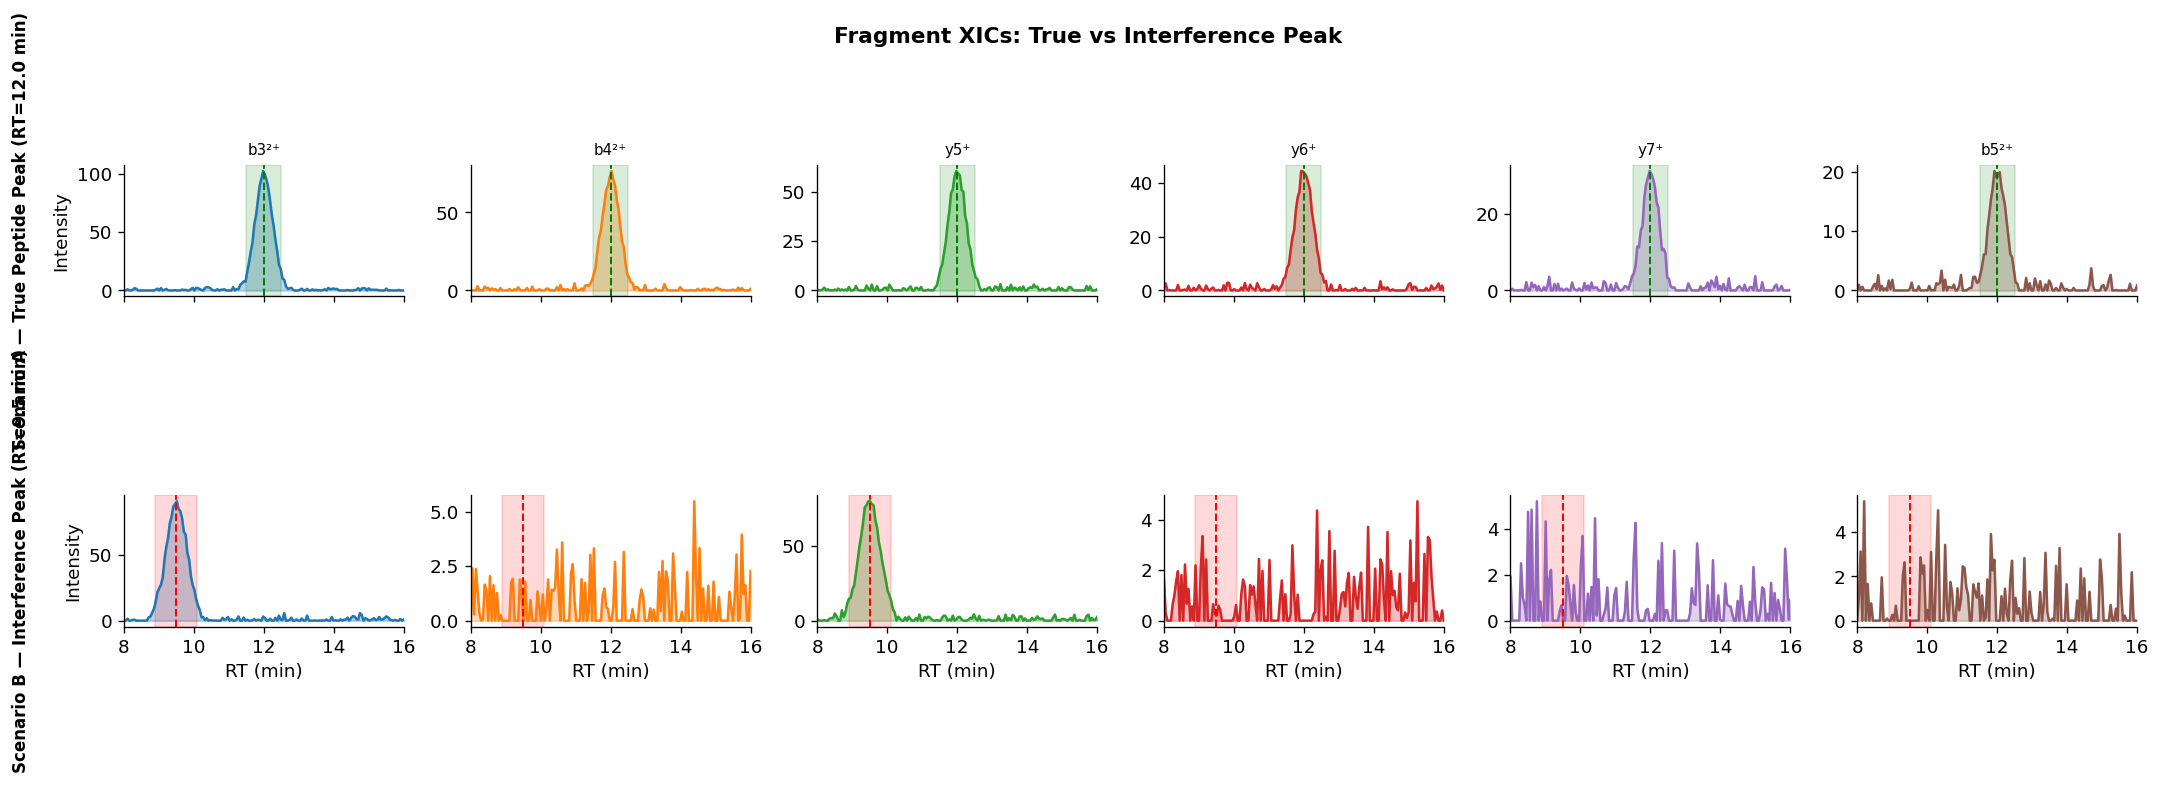

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharex=True)

titles = ['Scenario A — True Peptide Peak (RT=12.0 min)',
          'Scenario B — Interference Peak (RT=9.5 min)']
xics_both = [xics_A, xics_B]
boundaries = [boundary_A, boundary_B]
apices = [true_apex_rt, inter_apex_rt]

for row, (xics, bnd, apex, title) in enumerate(zip(xics_both, boundaries, apices, titles)):
    for col, (xic, color, label) in enumerate(zip(xics, frag_colors, frag_labels)):
        ax = axes[row, col]
        ax.fill_between(rt_full, xic, alpha=0.3, color=color)
        ax.plot(rt_full, xic, color=color, lw=1.5)
        ax.axvspan(bnd[0], bnd[1], alpha=0.15,
                   color='green' if row == 0 else 'red')
        ax.axvline(apex, color='green' if row == 0 else 'red', lw=1.2, ls='--')
        ax.set_xlim(rt_full[0], rt_full[-1])
        if row == 0:
            ax.set_title(label, fontsize=9)
        if col == 0:
            ax.set_ylabel('Intensity')
        if row == 1:
            ax.set_xlabel('RT (min)')

    # Row title on leftmost panel
    axes[row, 0].text(-0.4, 0.5, title, transform=axes[row, 0].transAxes,
                     fontsize=10, fontweight='bold', rotation=90, va='center')

plt.suptitle('Fragment XICs: True vs Interference Peak', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Compute Pairwise Correlations Within Peak Boundaries

For each pair of fragments, compute the **Pearson correlation** of their XICs **within
the peak integration window** (not the full XIC). This is important: if you correlate
over the full XIC, noise dominates and many pairs will be near zero even for a real peak.

In [4]:
def compute_coelution_features(xics, rt, boundary):
    """Compute pairwise correlations within [boundary[0], boundary[1]]."""
    mask = (rt >= boundary[0]) & (rt <= boundary[1])
    n = len(xics)
    
    pair_corrs = []
    for i, j in combinations(range(n), 2):
        r = pearson(xics[i][mask], xics[j][mask])
        pair_corrs.append((i, j, r))
    
    # Per-fragment average correlation with all other fragments
    per_frag_corr = np.zeros(n)
    count = np.zeros(n, dtype=int)
    for i, j, r in pair_corrs:
        per_frag_corr[i] += r
        per_frag_corr[j] += r
        count[i] += 1
        count[j] += 1
    per_frag_corr = np.where(count > 0, per_frag_corr / count, 0.0)
    
    # Correlation matrix (for heatmap)
    corr_matrix = np.eye(n)
    for i, j, r in pair_corrs:
        corr_matrix[i, j] = r
        corr_matrix[j, i] = r
    
    return {
        'pair_corrs': pair_corrs,
        'corr_matrix': corr_matrix,
        'per_frag_corr': per_frag_corr,
        'coelution_sum': sum(r for _, _, r in pair_corrs),
        'coelution_min': min(r for _, _, r in pair_corrs),
        'n_coeluting': int(np.sum(per_frag_corr > 0)),
    }

feats_A = compute_coelution_features(xics_A, rt_full, boundary_A)
feats_B = compute_coelution_features(xics_B, rt_full, boundary_B)

print('  Scenario A (true peak):        coelution_sum = {:6.2f}   min = {:5.2f}   n_coeluting = {}'.format(
    feats_A['coelution_sum'], feats_A['coelution_min'], feats_A['n_coeluting']))
print('  Scenario B (interference):     coelution_sum = {:6.2f}   min = {:5.2f}   n_coeluting = {}'.format(
    feats_B['coelution_sum'], feats_B['coelution_min'], feats_B['n_coeluting']))

  Scenario A (true peak):        coelution_sum =  14.83   min =  0.98   n_coeluting = 6
  Scenario B (interference):     coelution_sum =  -0.38   min = -0.33   n_coeluting = 3


## 4. Coelution Heatmaps

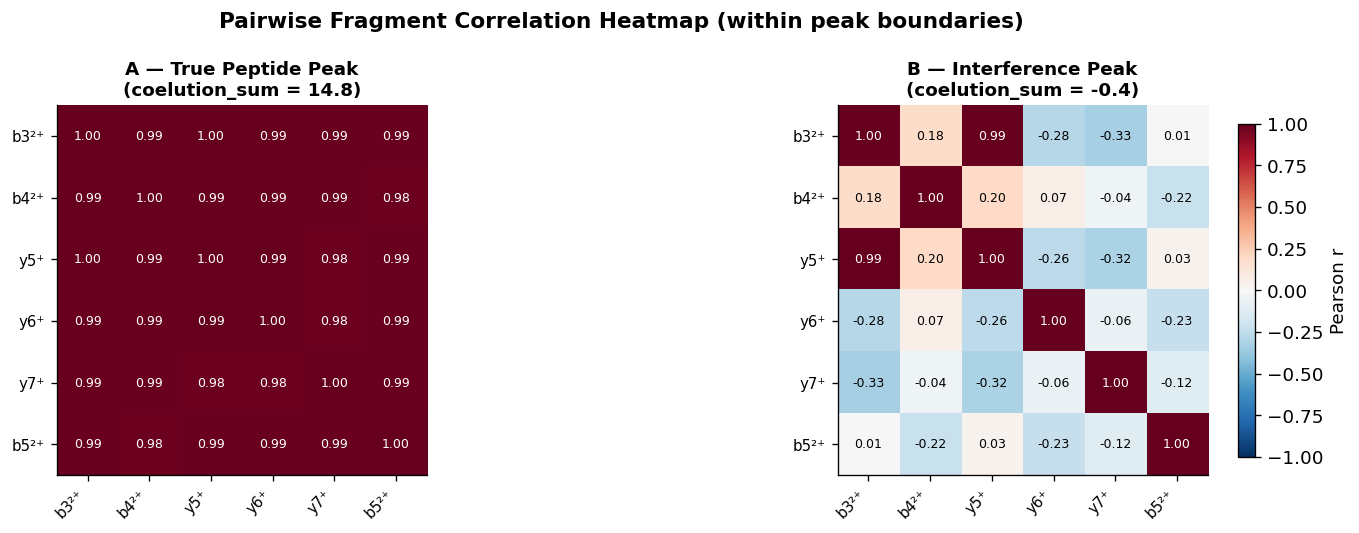

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, feats, scenario in zip(
    axes,
    [feats_A, feats_B],
    ['A — True Peptide Peak\n(coelution_sum = {:.1f})'.format(feats_A['coelution_sum']),
     'B — Interference Peak\n(coelution_sum = {:.1f})'.format(feats_B['coelution_sum'])],
):
    mat = feats['corr_matrix']
    n   = mat.shape[0]
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='equal')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(frag_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(frag_labels, fontsize=9)
    ax.set_title(scenario, fontsize=11, fontweight='bold')

    # Annotate cells
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                   fontsize=7.5, color='black' if abs(mat[i,j]) < 0.6 else 'white')

# Attach colorbar only to the right axes to avoid overlapping the left plot
cb = fig.colorbar(im, ax=axes[1], label='Pearson r', shrink=0.9, pad=0.04)
fig.suptitle('Pairwise Fragment Correlation Heatmap (within peak boundaries)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Per-Fragment Correlations (`fragment_corr_0..5`)

Rather than just the aggregate `coelution_sum`, Osprey passes the individual per-fragment
average correlations (`fragment_corr_0..5`) as separate PIN features. This lets the SVM
learn which fragments are typically the weakest links and weight them appropriately.

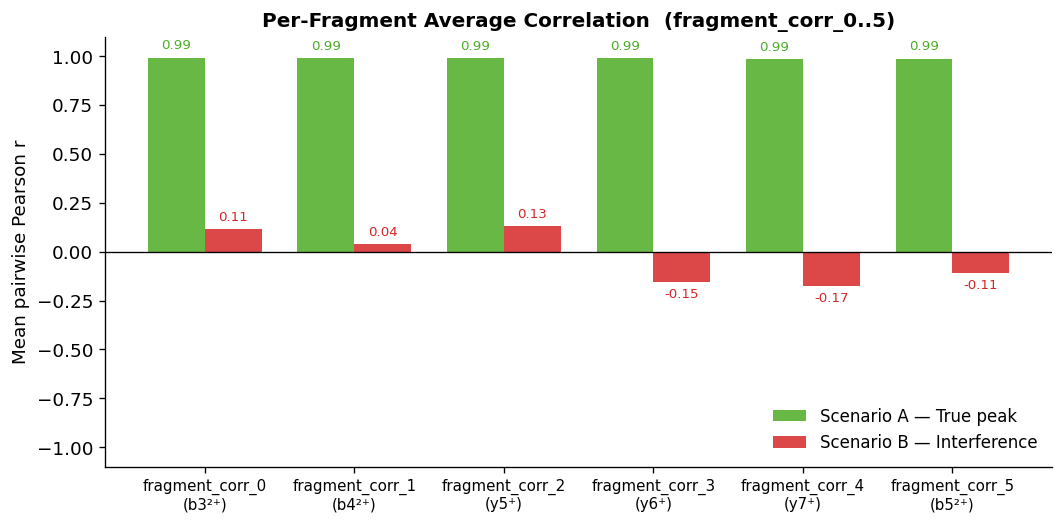

In [10]:
n_frags = 6
x = np.arange(n_frags)
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.5))

bars_A = ax.bar(x - width/2, feats_A['per_frag_corr'], width,
                color='#4dac26', alpha=0.85, label='Scenario A — True peak')
bars_B = ax.bar(x + width/2, feats_B['per_frag_corr'], width,
                color='#d62728', alpha=0.85, label='Scenario B — Interference')

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f'fragment_corr_{i}\n({frag_labels[i]})' for i in range(n_frags)], fontsize=9)
ax.set_ylabel('Mean pairwise Pearson r')
ax.set_ylim(-1.1, 1.1)
ax.set_title('Per-Fragment Average Correlation  (fragment_corr_0..5)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, frameon=False, loc='lower right')

# Annotate with values
for bar in bars_A:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 0.03, f'{y:.2f}',
            ha='center', va='bottom', fontsize=8, color='#4dac26')
for bar in bars_B:
    y = bar.get_height()
    va_ = 'bottom' if y >= 0 else 'top'
    off_ = 0.03 if y >= 0 else -0.03
    ax.text(bar.get_x() + bar.get_width()/2, y + off_, f'{y:.2f}',
            ha='center', va=va_, fontsize=8, color='#d62728')

plt.tight_layout()
plt.show()


## 6. Elution-Weighted Cosine Similarity

The **elution-weighted cosine** (`elution_weighted_cosine`) measures how consistently the
observed spectral pattern matches the library across all scans within the peak —
not just at the apex.

At each scan within the peak, a cosine similarity (after √-intensity preprocessing and
L2 normalisation) is computed between the observed spectrum and the library.  Each scan's
cosine is weighted by the **score²** (higher weight where the peptide
signal is strongest), then the weighted average is returned.

$$\text{elution\_weighted\_cosine} = \frac{\sum_s c_s^2 \cdot \text{cos}(\hat{o}_s, \hat{l})}{\sum_s c_s^2}$$

This score is low when interference corrupts part of the peak but not the apex.

Elution-weighted cosine  — Scenario A (true):      0.9998
Elution-weighted cosine  — Scenario B (interfere): 0.7419


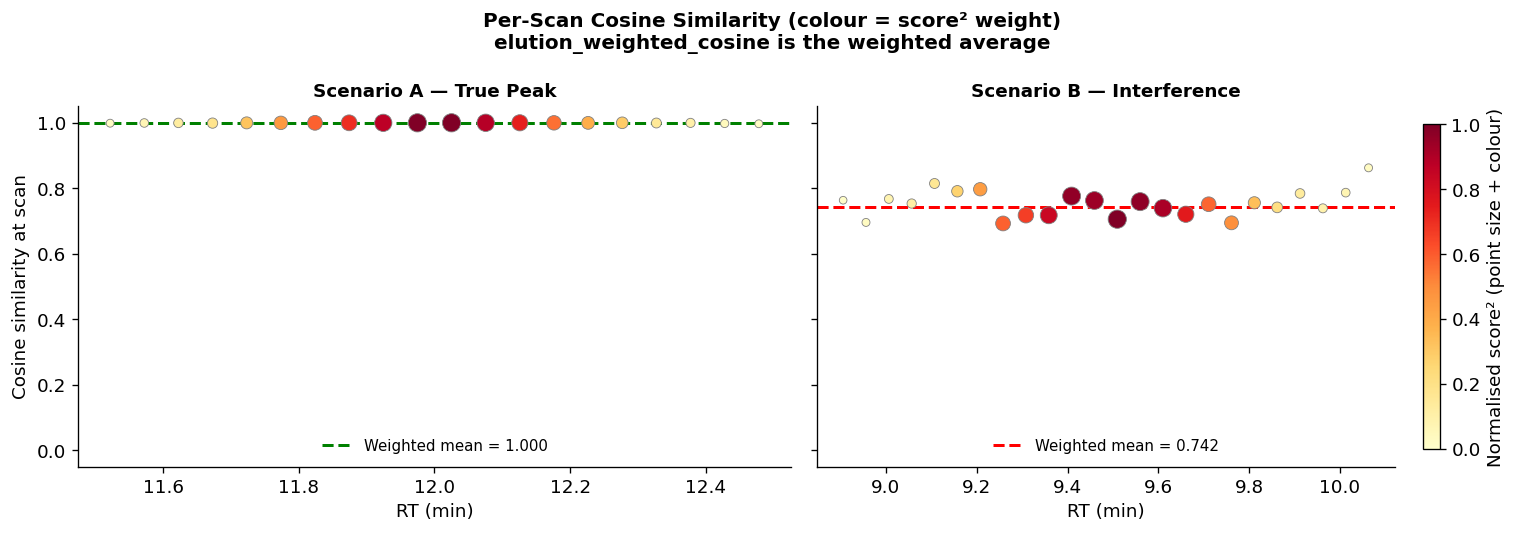

In [13]:
def cosine_at_scan(observed_intensities, library_intensities):
    """Sqrt-preprocessed, L2-normalised cosine. Unmatched library fragments get 0."""
    lib = np.sqrt(np.asarray(library_intensities, dtype=float))
    obs = np.sqrt(np.asarray(observed_intensities, dtype=float))
    norm_lib = np.linalg.norm(lib)
    norm_obs = np.linalg.norm(obs)
    if norm_lib < 1e-10 or norm_obs < 1e-10:
        return 0.0
    return float(np.dot(lib / norm_lib, obs / norm_obs))


def elution_weighted_cosine(xics, coef_series, rt, lib_ints, boundary):
    """Score²-weighted average cosine across scans within [boundary[0], boundary[1]]."""
    mask = (rt >= boundary[0]) & (rt <= boundary[1]) & (coef_series > 0)
    rts_in = rt[mask]
    coefs_in = coef_series[mask]

    cosines = []
    for idx in np.where(mask)[0]:
        obs_at_scan = np.array([xic[idx] for xic in xics])
        cosines.append(cosine_at_scan(obs_at_scan, lib_ints))

    weights = coefs_in ** 2
    if weights.sum() < 1e-10:
        return 0.0, rts_in, np.array(cosines), weights

    ew_cos = float(np.dot(cosines, weights) / weights.sum())
    return ew_cos, rts_in, np.array(cosines), weights


ewc_A, rts_A, cos_A, wts_A = elution_weighted_cosine(xics_A, coef_A, rt_full, lib_ints, boundary_A)
ewc_B, rts_B, cos_B, wts_B = elution_weighted_cosine(xics_B, coef_B, rt_full, lib_ints, boundary_B)

print(f'Elution-weighted cosine  — Scenario A (true):      {ewc_A:.4f}')
print(f'Elution-weighted cosine  — Scenario B (interfere): {ewc_B:.4f}')

# ── Visualise per-scan cosine traces ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

scenarios = [
    ('A — True Peak', rts_A, cos_A, wts_A, boundary_A, 'green', ewc_A),
    ('B — Interference', rts_B, cos_B, wts_B, boundary_B, 'red',  ewc_B),
]

for ax, (name, rts, cos, wts, bnd, color, mean_cos) in zip(axes, scenarios):
    wts_norm = wts / wts.max() if wts.max() > 0 else wts
    sc = ax.scatter(rts, cos, c=wts_norm, cmap='YlOrRd', s=wts_norm*100+20,
                    edgecolors='gray', linewidths=0.5, vmin=0, vmax=1, zorder=4)
    ax.axhline(mean_cos, ls='--', lw=1.8, color=color,
               label=f'Weighted mean = {mean_cos:.3f}')
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('RT (min)')
    ax.set_title(f'Scenario {name}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=9, frameon=False, loc='lower center')

axes[0].set_ylabel('Cosine similarity at scan')
# Attach colorbar only to the right axes to avoid overlapping the left plot
fig.colorbar(sc, ax=axes[1], label='Normalised score² (point size + colour)', pad=0.04, shrink=0.9)
fig.suptitle('Per-Scan Cosine Similarity (colour = score² weight)\n'
             'elution_weighted_cosine is the weighted average',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Summary Comparison

The spectral scores are similar in both scenarios, but the coelution features
cleanly separate them.

Feature                            Scenario A (true)   Scenario B (interference)
────────────────────────────────────────────────────────────────────────
  Apex score (normalised)                 1.002                0.889
  coelution_sum                          14.834               -0.385
  coelution_min                           0.982               -0.329
  n_coeluting                             6.000                3.000
  elution_weighted cosine                 1.000                0.742


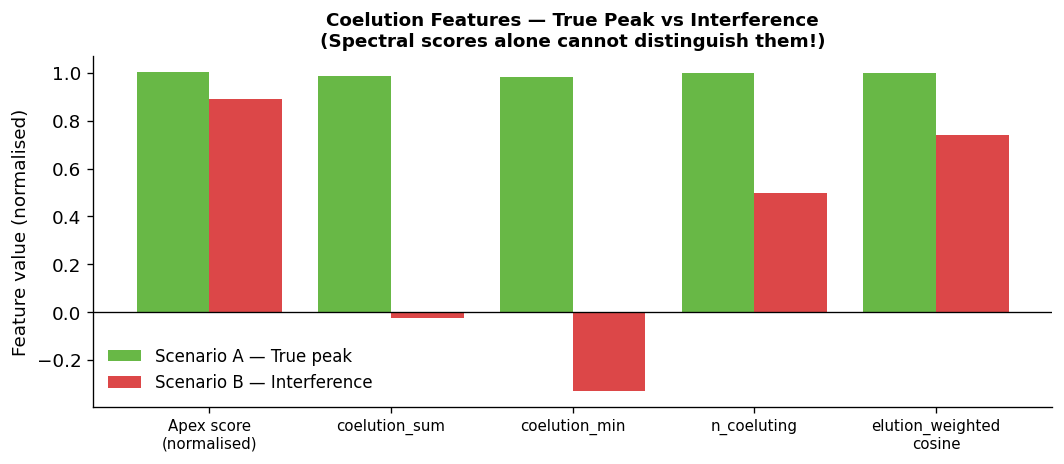

Saved: fragment_coelution.png


In [ ]:
feature_names = [
    'Apex score\n(normalised)',
    'coelution_sum',
    'coelution_min',
    'n_coeluting',
    'elution_weighted\ncosine',
]

# Spectral scores (normalised to max = 1)
apex_coef_A = coef_A[np.argmin(np.abs(rt_full - true_apex_rt))]
apex_coef_B = coef_B[np.argmin(np.abs(rt_full - inter_apex_rt))]

vals_A = [
    apex_coef_A,
    feats_A['coelution_sum'],
    feats_A['coelution_min'],
    feats_A['n_coeluting'],
    ewc_A,
]
vals_B = [
    apex_coef_B,
    feats_B['coelution_sum'],
    feats_B['coelution_min'],
    feats_B['n_coeluting'],
    ewc_B,
]

print('Feature                            Scenario A (true)   Scenario B (interference)')
print('─' * 72)
for name, a, b in zip(feature_names, vals_A, vals_B):
    nm = name.replace('\n', ' ')
    print(f'  {nm:<30}   {a:>12.3f}         {b:>12.3f}')

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(feature_names))
w = 0.4

# Normalise vals for display (different units)
scale = [1.0, 1/15, 1.0, 1/6, 1.0]   # rough normalisation per feature
vals_A_norm = [v * s for v, s in zip(vals_A, scale)]
vals_B_norm = [v * s for v, s in zip(vals_B, scale)]

ax.bar(x - w/2, vals_A_norm, w, color='#4dac26', alpha=0.85, label='Scenario A — True peak')
ax.bar(x + w/2, vals_B_norm, w, color='#d62728', alpha=0.85, label='Scenario B — Interference')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(feature_names, fontsize=9)
ax.set_ylabel('Feature value (normalised)')
ax.set_title('Coelution Features — True Peak vs Interference\n'
             '(Spectral scores alone cannot distinguish them!)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10, frameon=True, loc='upper left',
          bbox_to_anchor=(0.01, 0.99), bbox_transform=ax.transAxes)
plt.tight_layout()
plt.savefig('fragment_coelution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fragment_coelution.png')
